# 2. Machine Learning for Regression

In [1]:
import pandas as pd
import numpy as np

### 2.2 Data Preparation

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
# !wget $data

In [4]:
!ls -lrt

total 1624
-rw-rw-rw- 1 codespace codespace 1475504 Mar 22 06:01 data.csv
-rw-rw-rw- 1 codespace codespace  181736 Mar 27 12:29 car-price-prediction.ipynb


In [5]:
df = pd.read_csv('data.csv')

In [6]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [7]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [10]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [11]:
df.dtypes == 'str'

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [12]:
string_cols = list(df.dtypes[df.dtypes == 'str'].index) # getting string columns with dtypes and then convering to pythong list
string_cols

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [13]:
for col in string_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [14]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### 2.3 Exploratory data analysis

In [15]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique)
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
<bound method IndexOpsMixin.nunique of 0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: str>

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
<bound method IndexOpsMixin.nunique of 0        1_series_m
1          1_series
2          1_series
3          1_series
4          1_series
            ...    
11909           zdx
11910           zdx
11911           zdx
11912           zdx
11913        zephyr
Name: model, Length: 11914, dtype: str>

year
[2011 2012 2013 1992 1993]
<bound method IndexOpsMixin.nunique of 0        2011
1        2011
2        2011
3        2011
4        2011
         ... 
11909    2012
11910    2012
11911    2012
11912    2013
11913    2006
Name: year, 

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

(array([9.098e+03, 2.003e+03, 3.170e+02, 1.320e+02, 1.110e+02, 9.200e+01,
        5.100e+01, 4.100e+01, 1.500e+01, 1.300e+01, 1.500e+01, 1.300e+01,
        4.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([2.00000000e+03, 4.32780400e+04, 8.45560800e+04, 1.25834120e+05,
        1.67112160e+05, 2.08390200e+05, 2.49668240e+05, 2.90946280e+05,
        3.32224320e+05, 3.73502360e+05, 4.14780400e+05, 4.56058440e+05,
        4.97336480e+05, 5.38614520e+05, 5.79892560e+05, 6.21170600e+05,
        6.62448640e+05, 7.03726680e+05, 7.45004720e+05, 7.86282760e+05,
        8.275608

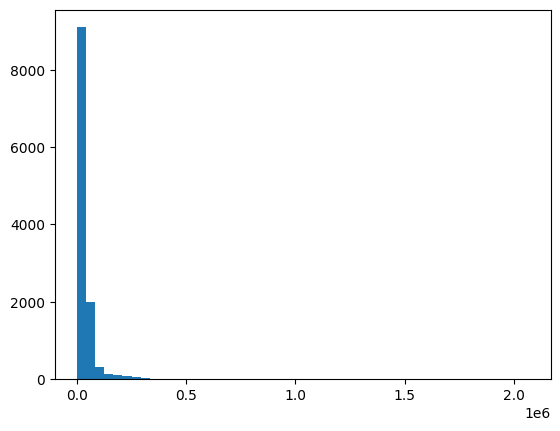

In [17]:
plt.hist(df.msrp, bins=50) # data seems to have long tail (0.5 to 2.0) check plotting. this mean data is not distributed well

(array([1571.,   55.,   13.,    7.,   20.,   53.,  223.,  305.,  371.,
         508.,  621.,  684.,  710.,  622.,  637.,  581.,  527.,  467.,
         408.,  365.,  332.,  274.,  250.,  203.,  189.,  153.,  123.,
         102.,   71.,   85.,   85.,   92.,   66.,   49.,   46.,   33.,
          29.,   36.,   24.,   39.,   21.,   39.,   31.,   22.,   32.,
          19.,   23.,   21.,   18.,   21.]),
 array([ 2000.,  3959.,  5918.,  7877.,  9836., 11795., 13754., 15713.,
        17672., 19631., 21590., 23549., 25508., 27467., 29426., 31385.,
        33344., 35303., 37262., 39221., 41180., 43139., 45098., 47057.,
        49016., 50975., 52934., 54893., 56852., 58811., 60770., 62729.,
        64688., 66647., 68606., 70565., 72524., 74483., 76442., 78401.,
        80360., 82319., 84278., 86237., 88196., 90155., 92114., 94073.,
        96032., 97991., 99950.]),
 <BarContainer object of 50 artists>)

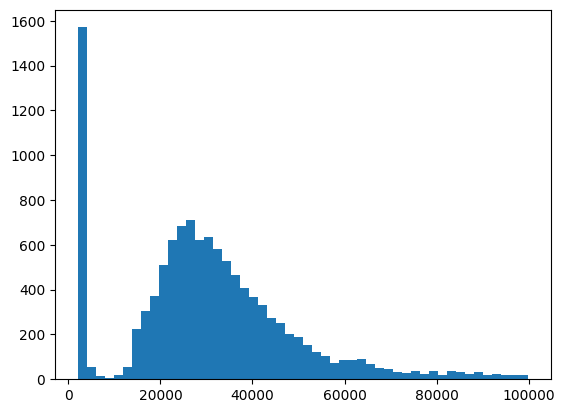

In [18]:
plt.hist(df.msrp[df.msrp < 100000], bins=50) # filtering msrp will have normal data distribution for price. but we are excluding lots of data

In [19]:
# converting below values in log can been seen is more closer
np.log([1, 10, 1000, 100000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

In [20]:
# if values have zero then it wil complain. To handle this we add 1 to all the values.`
np.log([0, 1, 10, 1000, 100000]) 

/tmp/ipykernel_3415/3257606447.py:2: RuntimeWarning: divide by zero encountered in log
  np.log([0, 1, 10, 1000, 100000])


array([       -inf,  0.        ,  2.30258509,  6.90775528, 11.51292546])

In [21]:
# adding 1 to each value will handle zero case. for this numpy have in-built function. check next cell.
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1]) 

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [22]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

(array([1.211e+03, 1.230e+02, 9.900e+01, 9.200e+01, 4.800e+01, 2.300e+01,
        1.800e+01, 1.300e+01, 7.000e+00, 5.000e+00, 4.000e+00, 1.000e+01,
        2.300e+01, 5.300e+01, 2.630e+02, 3.850e+02, 6.410e+02, 1.000e+03,
        1.261e+03, 1.372e+03, 1.238e+03, 1.070e+03, 8.200e+02, 5.590e+02,
        3.490e+02, 2.280e+02, 1.870e+02, 1.500e+02, 9.700e+01, 7.700e+01,
        7.100e+01, 5.400e+01, 5.900e+01, 9.300e+01, 5.900e+01, 5.100e+01,
        3.700e+01, 1.400e+01, 2.100e+01, 1.900e+01, 3.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 4.000e+00,
        1.000e+00, 1.000e+00]),
 array([ 7.60140233,  7.74019585,  7.87898936,  8.01778287,  8.15657639,
         8.2953699 ,  8.43416341,  8.57295692,  8.71175044,  8.85054395,
         8.98933746,  9.12813098,  9.26692449,  9.405718  ,  9.54451151,
         9.68330503,  9.82209854,  9.96089205, 10.09968557, 10.23847908,
        10.37727259, 10.5160661 , 10.65485962, 10.79365313, 10.93244664,
        11.

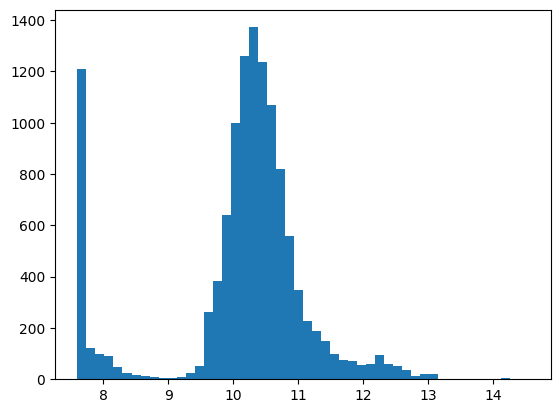

In [23]:
# We will convert value to log and plot as this will make distribution more closer to each other. As shown in examples above.
# after log value hist plot have normalise distribution and very less long tail values.
log_price = np.log1p(df.msrp)
plt.hist(log_price, bins=50)

##### Missing values

In [24]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### 2.4 Setting up the validation framework

In [25]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [26]:
n_train, n_val, n_test

(7150, 2382, 2382)

##### getting random sequece of data from dataframe for train

In [27]:
idx = np.arange(n)
rng = np.random.default_rng(seed=0)
rng.shuffle(idx)

In [28]:
idx

array([11744,  7096,   414, ...,  5921, 11215,   607], shape=(11914,))

In [29]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train: n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [30]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11744,nissan,xterra,2013,regular_unleaded,261.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2009,26900
7096,mazda,mx-3,1993,regular_unleaded,130.0,6.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,26,20,586,2000
414,bmw,4_series_gran_coupe,2015,premium_unleaded_(required),240.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,33,22,3916,42300
9142,cadillac,seville,2002,regular_unleaded,300.0,8.0,automatic,front_wheel_drive,4.0,"luxury,performance",large,sedan,25,16,1624,49705
1495,cadillac,ats_coupe,2015,premium_unleaded_(recommended),272.0,4.0,automatic,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,31,21,1624,47095


In [31]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [32]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,nissan,xterra,2013,regular_unleaded,261.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,2009,26900
1,mazda,mx-3,1993,regular_unleaded,130.0,6.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,26,20,586,2000
2,bmw,4_series_gran_coupe,2015,premium_unleaded_(required),240.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,33,22,3916,42300
3,cadillac,seville,2002,regular_unleaded,300.0,8.0,automatic,front_wheel_drive,4.0,"luxury,performance",large,sedan,25,16,1624,49705
4,cadillac,ats_coupe,2015,premium_unleaded_(recommended),272.0,4.0,automatic,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,31,21,1624,47095


In [33]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,dodge,dakota,2009,regular_unleaded,210.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,compact,extended_cab_pickup,20,15,1851,23710
1,gmc,s-15,1990,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,regular_cab_pickup,19,15,549,2000
2,bmw,3_series,2015,premium_unleaded_(required),180.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,35,23,3916,34950
3,aston_martin,dbs,2012,premium_unleaded_(required),510.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,high-performance",midsize,convertible,18,12,259,290861
4,volkswagen,tiguan,2016,premium_unleaded_(recommended),200.0,4.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,26,20,873,33365


In [34]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,nissan,altima,2015,regular_unleaded,270.0,6.0,automatic,front_wheel_drive,4.0,performance,midsize,sedan,32,22,2009,29830
1,volkswagen,golf_r,2015,premium_unleaded_(recommended),292.0,4.0,automated_manual,all_wheel_drive,4.0,"hatchback,factory_tuner,high-performance",compact,4dr_hatchback,30,23,873,39090
2,lotus,exige,2011,premium_unleaded_(recommended),240.0,4.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,26,20,613,65690
3,hyundai,elantra,2016,regular_unleaded,145.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,38,28,1439,19700
4,ford,focus,2017,electric,NaN,0.0,direct_drive,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,99,110,5657,29120


In [35]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [36]:
# extracting target value (in this dataset price `msrp` is the target value): g(X) ~ y, keep it as log value.
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [37]:
y_train

array([10.19991874,  7.60140233, 10.65256601, ..., 10.57543663,
        7.60140233, 10.49241246], shape=(7150,))

In [38]:
len(y_train), len(y_val), len(y_test)

(7150, 2382, 2382)

In [39]:
# deleting msrp so that this column is not used in training by mistake.

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

### 2.5 Linear regression

In [40]:
df_train.iloc[453] # random index value for checking

make                            nissan
model                           sentra
year                              2016
engine_fuel_type      regular_unleaded
engine_hp                        130.0
engine_cylinders                   4.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category                    NaN
vehicle_size                   midsize
vehicle_style                    sedan
highway_mpg                         38
city_mpg                            29
popularity                        2009
Name: 453, dtype: object

#### formula
for single vector: 

$g(x_n) = w_0 + \sum_{i=1}^{n} w_i x_i$


*$w_0$ is the bias term (the base value).


#### applying the formula

If we expand the summation ($\sum$) for our 3 features, the linear regression formula looks like this:

for index 453 from data set (here this number only represent data for 453 row):

$g(x_{453}) = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_3$


In [41]:
xi = [453, 11, 86] # feature value for index 453 [engine_hp, city_mpg, popularity]
w0 = 7.17 # bias term (base value)
w = [0.01, 0.04, 0.002] # each feature weight (taken some random number, later understand how to calculate)

In [42]:
def linear_regression(xi):
    n = len(xi)
    prediction = w0
    for j in range(n):
        prediction = prediction + (xi[j] * w[j])

    return prediction
    

In [43]:
pred = linear_regression(xi)
pred

12.312

In [44]:
# Converting to actual value using exponention as prices were conveted to log earlier
pred_msrp = np.expm1(pred)
pred_msrp

np.float64(222347.2221101062)

In [45]:
np.log1p(pred_msrp) # verification

np.float64(12.312)

### 2.6 Linear regression vector form

In [46]:
def dot(xi, w):
    n = len(xi)

    res = 0.0
    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [47]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [48]:
linear_regression(xi)

12.312000000000001

We stack an array of `1`s to our feature matrix `X` and prepend the bias `w0` to our weights `w` to simplify the linear regression formula. This "bias trick" allows us to compute the entire prediction—including the base value—using a single, efficient vector dot product ($X \cdot w_{new}$).

multiplying `bias term` ($w_0$) with `1` will result same  ($w_0$)

$g(x_n) = \sum_{i=0}^{n} w_i x_i$

where
  - $x_0 = 1$
  - $w_0$ is bias term.


In [49]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [50]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [51]:
def linear_regression_np_dot(X):
    return X.dot(w_new)

In [52]:
linear_regression_np_dot(X)

array([12.38 , 13.552, 12.312])

###  2.7 Training a linear regression model

In [53]:
def train_linear_regression(X, y):
    pass

In [54]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [55]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [56]:
X = np.column_stack([ones, X]) # stacking 1 to feature matrix. explaination given above.
X

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [57]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

### understading the formula for weight calculation.
-  funciton that define linear regression: $g(X) \approx y$
- function is dot product of featuere matrix $X$ and $w$: $g(X) = X w$
- $X w \approx y$
- $ X^{-1} X w \approx X^{-1} y $
- $w \approx X^{-1} y $
> if X is square matrix then this is valid. inverse can be found only for square matrix


# Deriving the Normal Equation
Since $X$ is not a square matrix, we cannot use $X^{-1}$. We multiply by the transpose $X^T$ to create a square matrix ($X^T X$) that can be inverted.

- Start with the linear system:
$Xw \approx y$

- Multiply both sides by $X^T$ to get a square matrix:
$X^T X w = X^T y$


- Multiply by the inverse of the Gram Matrix $(X^T X)^{-1}$:
$(X^T X)^{-1} X^T X w = (X^T X)^{-1} X^T y$


- The identity matrix $I = (X^T X)^{-1} X^T X$ cancels out:
$w = (X^T X)^{-1} X^T y$

In [58]:
XTX = X.T.dot(X) # Creating gram matrix
XTX_inv = np.linalg.inv(XTX) # Creating inverse of gram matrix
w_full = XTX_inv.dot(X.T).dot(y) # accoring to formula derived above. dot product of inverse gram matrix and transpose of X matrix then dot with y

In [59]:
w_full

array([ 2.58447541e+04, -1.60890647e+01, -1.99472549e+02, -1.22802883e+00])

In [60]:
w0 = w_full[0]
w = w_full[1:]

In [61]:
w0, w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [62]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X) 
    XTX_inv = np.linalg.inv(XTX) 
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]
    

In [63]:
X = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
])

In [64]:
train_linear_regression(X, y)

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

### 2.8 Car price baseline model

In [65]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [66]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [67]:
w0, w

(np.float64(7.9698513950099565),
 array([ 9.55319875e-03, -1.55385591e-01,  1.53608914e-02,  1.25939128e-02,
        -3.66794572e-06]))

In [68]:
y_pred

array([10.01968034,  8.9285657 , 10.41068855, ..., 10.31022191,
        8.97310133, 10.45114846], shape=(7150,))

<Axes: ylabel='Count'>

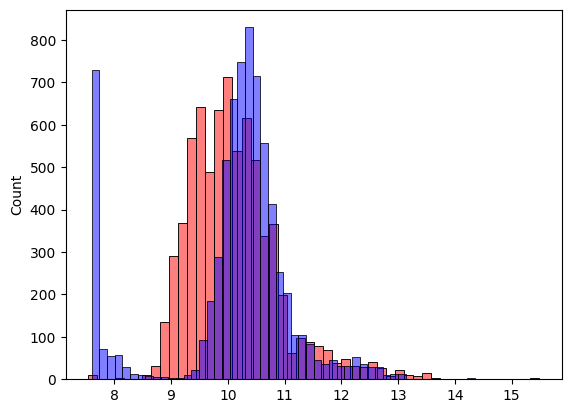

In [69]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

### 2.9 RMSE

The RMSE is a standard way to measure the error of a model in predicting quantitative data.

$RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2}$

- predicted value $\hat{y}_i$
- actual value $y_i$

In [70]:
def rmse(y, y_pred):
    error = y_pred - y
    square_error = error ** 2
    mean_square_error = square_error.mean()
    square_root_mean_square = np.sqrt(mean_square_error)

    return square_root_mean_square

In [71]:
rmse(y_train, y_pred)

np.float64(0.7547783824473304)

### 2.10 Validating the model

In [72]:
# this function is replica of step done above for preparation
def prepare_X(df):
    df_num = df[base] 
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [73]:
X_train = prepare_X(df_train)
X_train

array([[ 261.,    6.,   20.,   15., 2009.],
       [ 130.,    6.,   26.,   20.,  586.],
       [ 240.,    4.,   33.,   22., 3916.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 141.,    6.,   24.,   18., 1851.],
       [ 245.,    4.,   32.,   22., 1720.]], shape=(7150, 5))

In [74]:
w0, w = train_linear_regression(X_train, y_train)

In [75]:
w0, w

(np.float64(7.9698513950099565),
 array([ 9.55319875e-03, -1.55385591e-01,  1.53608914e-02,  1.25939128e-02,
        -3.66794572e-06]))

In [76]:
# Using validation dataset for validation.
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

In [77]:
y_pred

array([ 9.53304674,  9.04480157,  9.88081232, ..., 10.39700844,
        9.28705633,  9.12723209], shape=(2382,))

In [78]:
rmse(y_val, y_pred)

np.float64(0.7446582051087162)

### 2.11 Simple feature engineering

In [79]:
# adding age feature in existing feature to check prediction improves
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [80]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.515254300171569)

In [81]:
0.7446582051087162 # rsme without year feature
0.515254300171569 # improves rmse with year feature

0.515254300171569

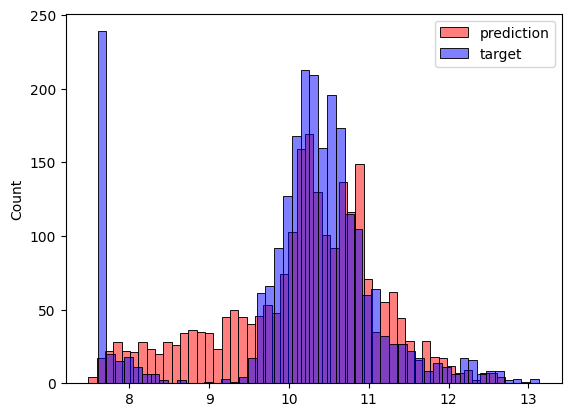

In [82]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

### 2.12 Categorical variables

In [83]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [84]:
categorical

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'model': ['silverado_1500',
  'tundra',
  'f-150',
  'beetle_convertible',
  'tacoma'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'luxury',
  'flex_fuel',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [87]:
features = []
for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

features

['make_chevrolet',
 'make_ford',
 'make_volkswagen',
 'make_toyota',
 'make_dodge',
 'model_silverado_1500',
 'model_tundra',
 'model_f-150',
 'model_beetle_convertible',
 'model_tacoma',
 'engine_fuel_type_regular_unleaded',
 'engine_fuel_type_premium_unleaded_(required)',
 'engine_fuel_type_premium_unleaded_(recommended)',
 'engine_fuel_type_flex-fuel_(unleaded/e85)',
 'engine_fuel_type_diesel',
 'driven_wheels_front_wheel_drive',
 'driven_wheels_rear_wheel_drive',
 'driven_wheels_all_wheel_drive',
 'driven_wheels_four_wheel_drive',
 'market_category_crossover',
 'market_category_luxury',
 'market_category_flex_fuel',
 'market_category_luxury,performance',
 'market_category_hatchback',
 'vehicle_size_compact',
 'vehicle_size_midsize',
 'vehicle_size_large',
 'vehicle_style_sedan',
 'vehicle_style_4dr_suv',
 'vehicle_style_coupe',
 'vehicle_style_convertible',
 'vehicle_style_4dr_hatchback']

In [86]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [88]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(121.13228244256545)

In [90]:
w0, w

(np.float64(2.874535733299307e+16),
 array([-3.99119033e-01,  1.40259878e+01,  1.01958595e+00, -6.24140237e+00,
        -5.13196245e-04, -8.87414044e-01, -5.03638721e+03, -5.07960585e+03,
        -5.05195031e+03,  6.92657376e+00,  4.00620753e+00, -9.11249638e+00,
         1.69887350e+01, -9.52195088e+00,  2.73664557e+01,  3.52282240e+01,
         4.68821564e+01, -2.70223230e+00,  2.97116901e+01, -3.48821422e+01,
        -3.10215631e+01, -2.51206149e+01, -2.17205162e+01, -3.11142707e+01,
        -2.87453573e+16, -2.87453573e+16, -2.87453573e+16, -2.87453573e+16,
        -5.43798196e+00, -2.23338661e+01, -7.42665926e+00, -4.14451147e+01,
        -4.75134725e+01, -1.18269612e+02, -1.11348189e+02, -1.02734278e+02,
        -1.31550634e-01,  4.97528904e-03,  1.66941096e-01,  3.92651496e-01,
        -2.41799586e-01]))

### 2.13 Regularization

Regularization is a technique used to prevent a model from "overfitting" (becoming too complex). In linear regression, when we have many features or highly correlated data, the model tends to assign massive values to the weights ($w$) to perfectly fit every noise point in the training data.

Regularization adds a penalty to the cost function based on the size of the weights. This forces the model to keep the weights small, leading to a "smoother" prediction that generalizes better to new data.

In [92]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5],
]

X = np.array(X)
X

array([[4, 4, 4],
       [3, 5, 5],
       [5, 1, 1],
       [5, 4, 4],
       [7, 5, 5],
       [4, 5, 5]])

In [93]:
y= [1, 2, 3, 1, 2, 3]

In [94]:
XTX = X.T.dot(X)
XTX

array([[140, 111, 111],
       [111, 108, 108],
       [111, 108, 108]])

In [95]:
np.linalg.inv(XTX)

LinAlgError: Singular matrix

#### The matrix is "singular" because rows 1 and 2 (and columns 1 and 2) are exactly the same, meaning they provide no unique information. Mathematically, a matrix with duplicate rows has a determinant of zero and is impossible to invert.

To resolve that we will do regularization, add some small value to one of the cell.

In [99]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.001],
]

X = np.array(X)
X

array([[4.   , 4.   , 4.   ],
       [3.   , 5.   , 5.   ],
       [5.   , 1.   , 1.   ],
       [5.   , 4.   , 4.   ],
       [7.   , 5.   , 5.   ],
       [4.   , 5.   , 5.001]])

In [100]:
XTX = X.T.dot(X)
XTX

array([[140.      , 111.      , 111.004   ],
       [111.      , 108.      , 108.005   ],
       [111.004   , 108.005   , 108.010001]])

In [102]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 4.12729985e-02, -6.12088502e+01,  6.11635991e+01],
       [-6.12088502e+01,  1.39209949e+06, -1.39197213e+06],
       [ 6.11635991e+01, -1.39197213e+06,  1.39184483e+06]])

In [103]:
XTX_inv.dot(X.T).dot(y)

array([ 4.13227240e-01, -1.74498256e+03,  1.74490300e+03])

#### Handling Singularity with Regularization (Ridge Regression)
When the matrix $X^T X$ is singular (non-invertible) due to duplicate features or small data, we add a small value $\alpha$ to the diagonal. This is called **Regularization**.

The modified formula for weights becomes:

$w = (X^T X + \alpha I)^{-1} X^T y$

Where:
* $\alpha$ is the regularization parameter (a small number like 0.01 or 0.001).
* $I$ is the **Identity Matrix** (a matrix with 1s on the diagonal and 0s elsewhere).

In [106]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

XTX = np.array(XTX)
XTX

array([[1.       , 2.       , 2.       ],
       [2.       , 1.       , 1.0000001],
       [2.       , 1.0000001, 1.       ]])

In [107]:
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [108]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [110]:
XTX = XTX + 0.01 * np.eye(3) # adding alpha to gram matrix
XTX

array([[1.02     , 2.       , 2.       ],
       [2.       , 1.02     , 1.0000001],
       [2.       , 1.0000001, 1.02     ]])

In [111]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [112]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.46213276380939045)

-- rmse improved

### 2.14 Tuning the model

In [114]:
# finding different value for r (alpha), we can take best value.
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

0.0 2.874535733299307e+16 121.13228244256545
1e-05 7.35881930174569 0.4621609635532165
0.0001 7.358645741578428 0.4621607126266422
0.001 7.357042533315586 0.4621581274394822
0.1 7.192835176733494 0.4619218209046531
1 6.320080094234563 0.46163130772674144
10 4.749141615093867 0.4710051913714233


In [116]:
# r = we can check above rmse score can take best r value. lets take
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4621581274394822)

### 2.15 Using the model

#### As part of selection of best model config. we had train, validation and test data. 
#### We can now combine train and validation data for actaual model use so that it can be have more data for training 
#### and we can use test data from testing.

In [118]:
df_full_train = pd.concat([df_train, df_val])

In [119]:
df_full_train = df_full_train.reset_index(drop=True)

In [120]:
X_full_train = prepare_X(df_full_train)

In [121]:
X_full_train

array([[261.,   6.,  20., ...,   0.,   0.,   0.],
       [130.,   6.,  26., ...,   0.,   0.,   0.],
       [240.,   4.,  33., ...,   0.,   0.,   0.],
       ...,
       [290.,   6.,  24., ...,   0.,   0.,   0.],
       [ 98.,   4.,  41., ...,   0.,   0.,   1.],
       [155.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [122]:
y_full_train = np.concatenate([y_train, y_val])

In [123]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [124]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.4591342351790189)

In [125]:
# test with one of the data from test for actual price. this can be new data as well. 
car = df_test.iloc[20].to_dict()
car

{'make': 'infiniti',
 'model': 'qx56',
 'year': 2010,
 'engine_fuel_type': 'premium_unleaded_(recommended)',
 'engine_hp': 320.0,
 'engine_cylinders': 8.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'four_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': 'luxury',
 'vehicle_size': 'large',
 'vehicle_style': '4dr_suv',
 'highway_mpg': 17,
 'city_mpg': 12,
 'popularity': 190}

In [126]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,infiniti,qx56,2010,premium_unleaded_(recommended),320.0,8.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,17,12,190


In [127]:
X_small = prepare_X(df_small)

In [128]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.671843086121635)

In [129]:
np.expm1(y_pred)

np.float64(43123.35018825215)

In [130]:
np.expm1(y_test[20])

np.float64(59150.000000000015)